In [95]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [96]:
words = open('pokemon_names.txt', 'r').read().splitlines()    #reading data

In [97]:
#forming letter to index mapping and vice versa

chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}

In [98]:
block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], []
for w in words:
  context = [0] * block_size
  for ch in w + '.':
    ix = stoi[ch]
    X.append(context)
    Y.append(ix)
    #print(''.join(itos[i] for i in context), '--->', itos[ix])
    context = context[1:] + [ix] # crop and append
X = torch.tensor(X)
Y = torch.tensor(Y)

In [99]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([8838, 3]), torch.int64, torch.Size([8838]), torch.int64)

In [100]:
#spliting into train,validation, test datasets.

def build_dataset(words):  
  X, Y = [], []
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix]
  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y
import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1]) #80% train
Xval, Yval = build_dataset(words[n1:n2]) #10% valid
Xte, Yte = build_dataset(words[n2:]) # 10% test

torch.Size([7068, 3]) torch.Size([7068])
torch.Size([879, 3]) torch.Size([879])
torch.Size([891, 3]) torch.Size([891])


In [101]:
#creating the model

g = torch.Generator().manual_seed(2147483647)    #generator
C = torch.randn((27, 30), generator=g)    #embedding
W1 = torch.randn((90, 300), generator=g)    #weights for layer 1
b1 = torch.randn(300, generator=g)    #biases for layer 1
W2 = torch.randn((300, 27), generator=g)    #weights for layer 2
b2 = torch.randn(27, generator=g)    #biases for layer 2
parameters = [C, W1, b1, W2, b2]    #complete list of parameters

In [102]:
for p in parameters:
  p.requires_grad = True    #by default grad is false in pytorch setting it True to backpropogate

In [103]:
lre = torch.linspace(0, -3, 1000)
'''If somebody has followed Andrej Karapathy's MPL project they might notice
    that i have reversed the ranges for the exponenet generation,
    the reson i have did  so is that in ML models it's better to start with larger
    learning rates and move towards smaller ones as the iterations are made.
'''
lrs = 10**lre    #actual learing steps for the gradient descent

In [104]:
lri = []
lossi = []
stepi = []

In [105]:
for i in range(200000):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (70,))
  
  # forward pass
  emb = C[Xtr[ix]] # (70, 3, 30)
  h = torch.tanh(emb.view(-1, 90) @ W1 + b1) # (70, 90)
  logits = h @ W2 + b2 # (70, 27)
  loss = F.cross_entropy(logits, Ytr[ix])
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  #lr = lrs[i]
  lr = 0.1 if i < 100000 else 0.01
  for p in parameters:
      p.data += -lr * p.grad

  # track stats
  stepi.append(i)
  lossi.append(loss.log10().item())

print(loss.item())

1.2338815927505493


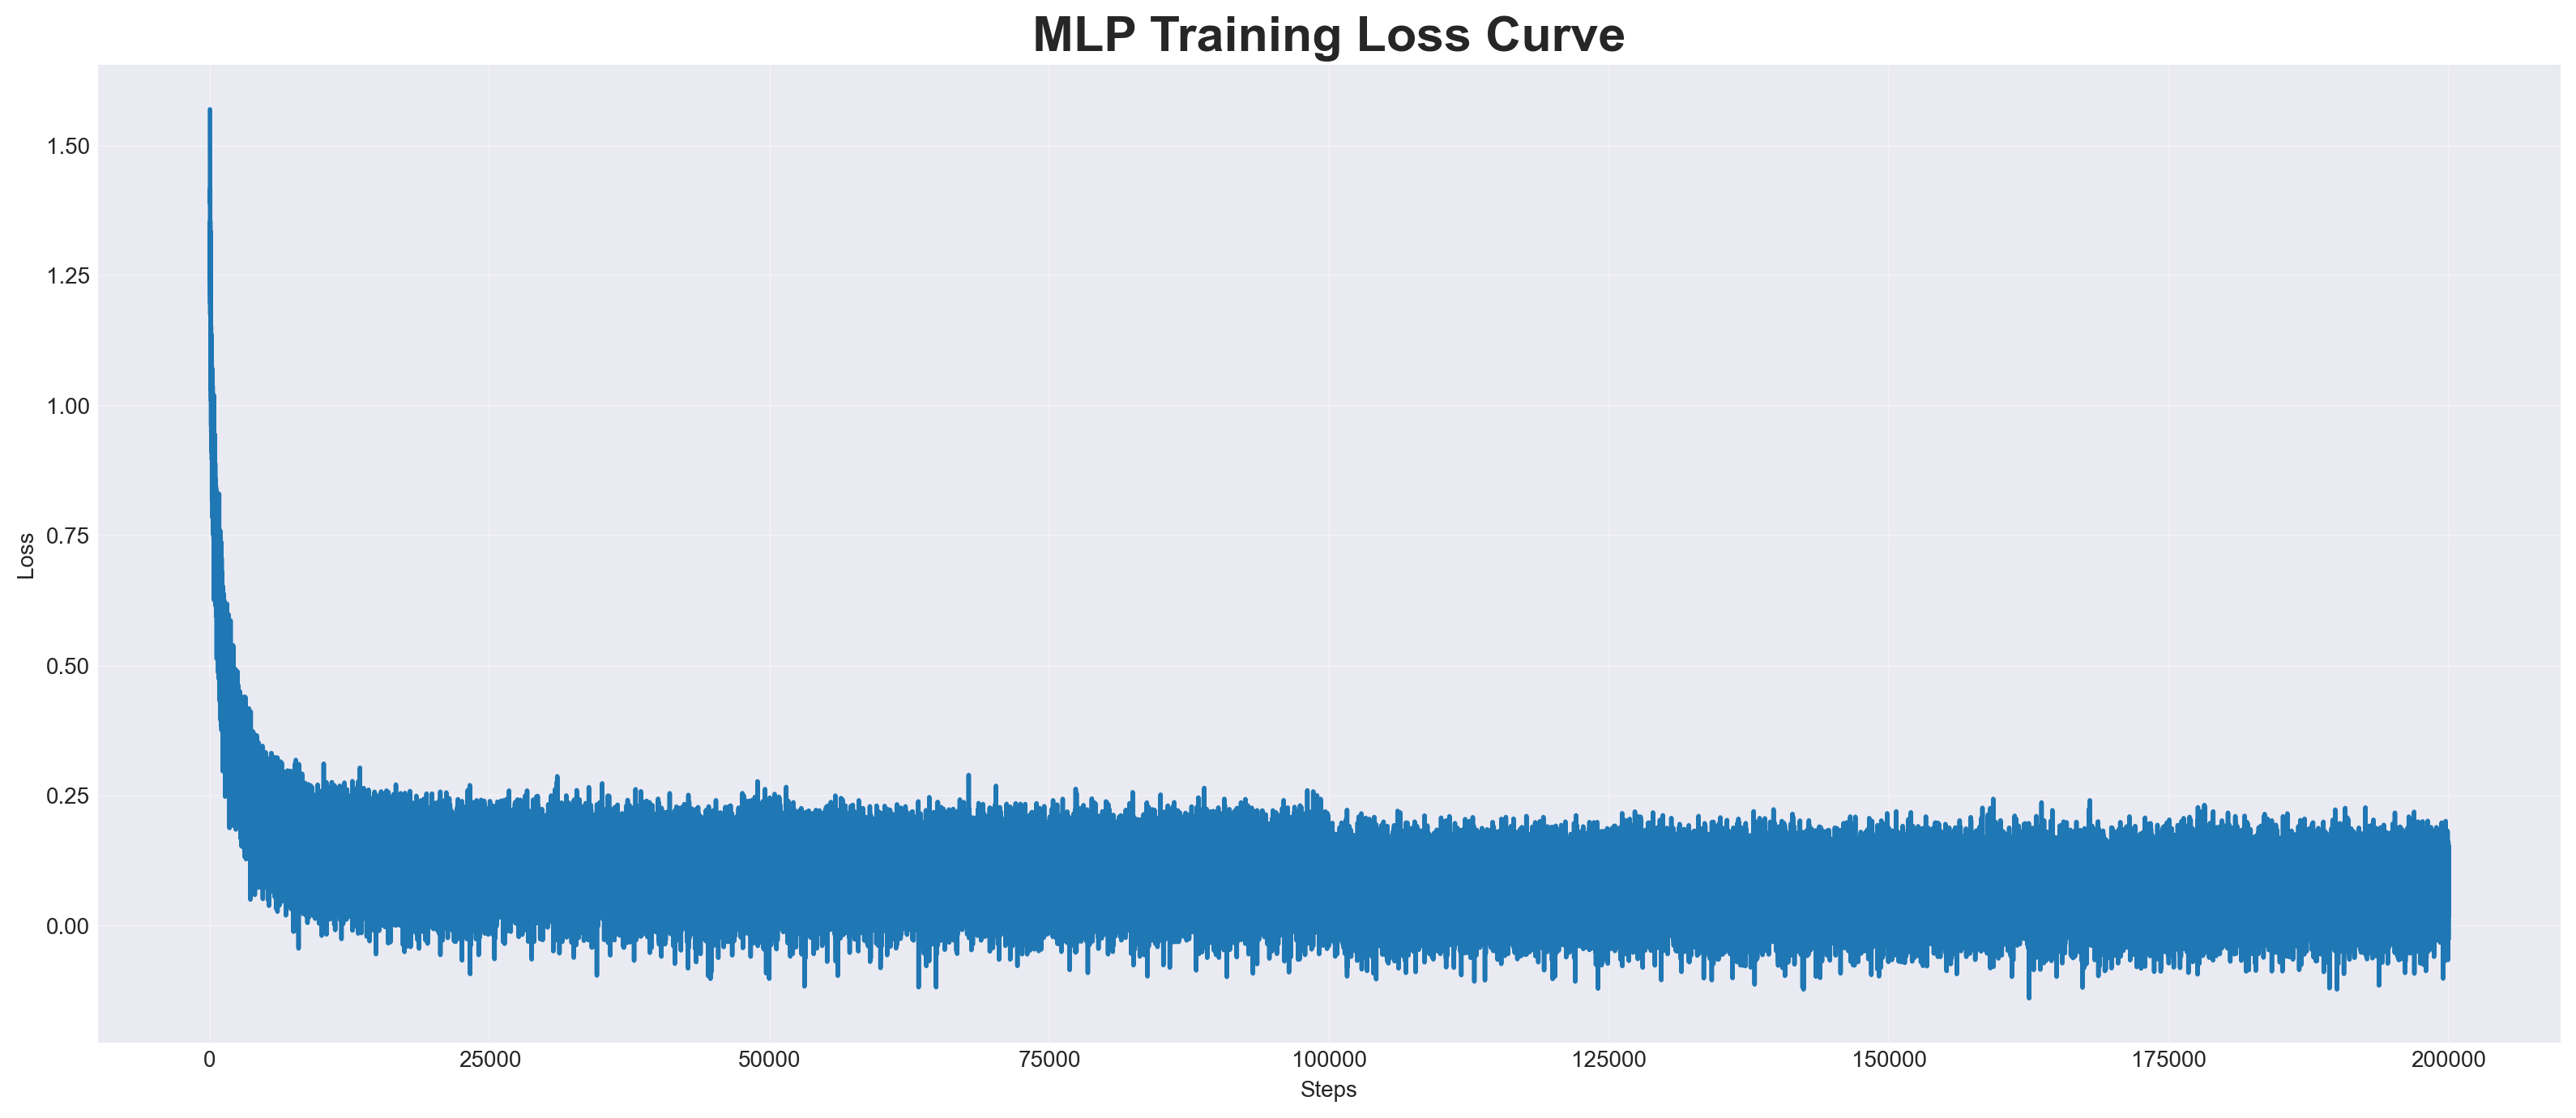

In [106]:
plt.style.use('seaborn-v0_8-dark')
plt.figure(figsize=(16,7),dpi=200)
plt.plot(stepi,lossi,lw=2)
plt.title('MLP Training Loss Curve',fontsize=22,fontweight='bold')
plt.xlabel('Steps'); plt.ylabel('Loss')
plt.grid(alpha=.3)
plt.tight_layout()
plt.savefig('training_loss.png',dpi=300,bbox_inches='tight')
plt.show()

In [107]:
#loss on complete data

emb = C[Xtr]
h = torch.tanh(emb.view(-1, 90) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr)
loss

tensor(1.1981, grad_fn=<NllLossBackward0>)

In [108]:
#loss on validation set

emb = C[Xdev] 
h = torch.tanh(emb.view(-1, 90) @ W1 + b1)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ydev)
loss

tensor(7.2850, grad_fn=<NllLossBackward0>)

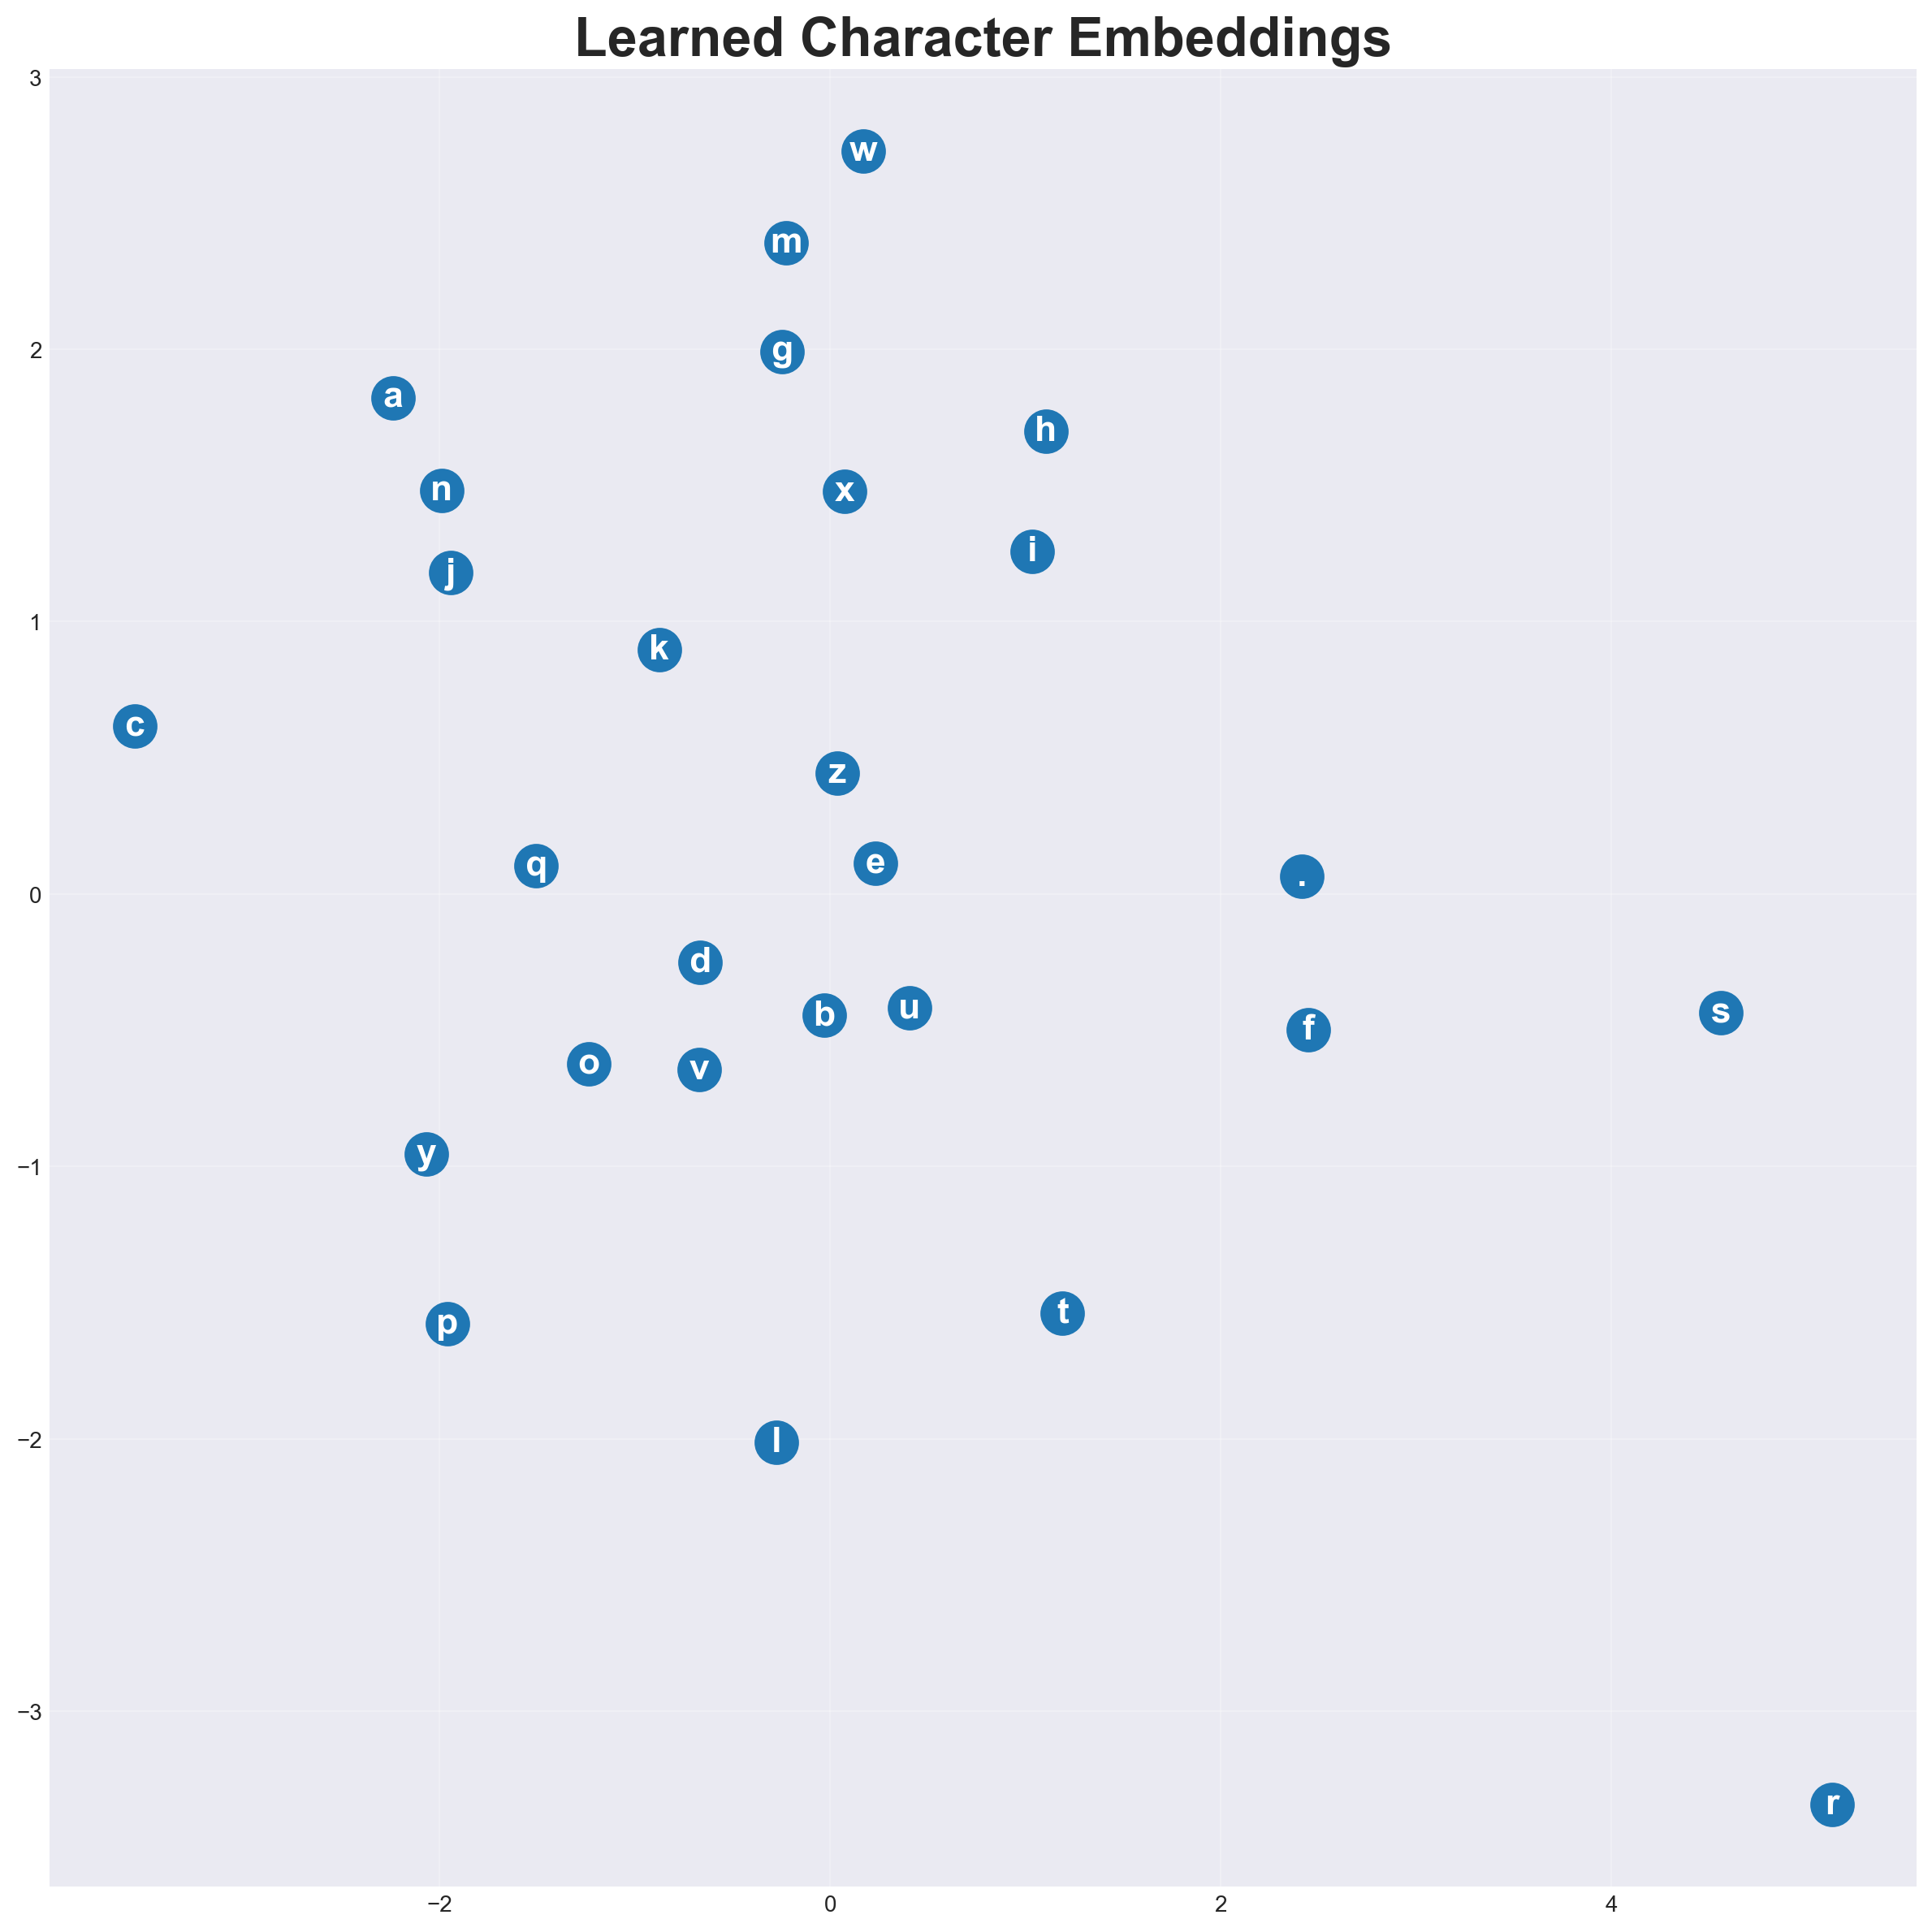

In [109]:
# visualize dimensions 0 and 1 of the embedding matrix C for all characters
plt.style.use('seaborn-v0_8-dark')
plt.figure(figsize=(12,12),dpi=200)

plt.scatter(C[:,0].data,C[:,1].data,s=350)

for i in range(C.shape[0]):
    plt.text(C[i,0].item(),C[i,1].item(),itos[i],ha='center',va='center',color='white',fontsize=16,fontweight='bold')

plt.title('Learned Character Embeddings',fontsize=24,fontweight='bold')
plt.grid(alpha=.25)
plt.tight_layout()
plt.savefig('character_embeddings.png',dpi=300,bbox_inches='tight')
plt.show()

In [110]:
context = [0] * block_size
C[torch.tensor([context])].shape

torch.Size([1, 3, 30])

In [111]:
#Trying to find the new Pokemon. Gotta catch'em all!
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))

cham.
hound.
hop.
flitle.
glash.
skartang.
machu.
flett.
happlett.
nectabutterior.
palafin.
haton.
crocks.
tox.
lile.
frigibarrok.
purus.
frigible.
pignite.
dred.


In [113]:
#Creating your own Mew?(sadly only name, i dont have money like Giovani to create pokemon itself T_T) Hope you enjoy!!!

g = torch.Generator().manual_seed(2147483647 + 10)
def generate_from_prefix(prefix,max_len=20):
    prefix=prefix.lower()
    if len(prefix)!=3: return print("Enter exactly 3 chars")
    context=[stoi[c] for c in prefix]
    out=list(prefix)
    while True:
        h=torch.tanh(C[torch.tensor([context])].view(1,-1)@W1+b1)
        p=F.softmax(h@W2+b2,dim=1)
        ix=torch.multinomial(p,1,generator=g).item()
        if ix==0 or len(out)>=max_len: break
        out.append(itos[ix])
        context=context[1:]+[ix]
    print("\nGenerated →","".join(out))
while True:
    s=input("\nEnter first 3 chars (q=quit): ")
    if s.lower()=="q": break
    generate_from_prefix(s)


Enter first 3 chars (q=quit):  zyg



Generated → zygeki



Enter first 3 chars (q=quit):  pik



Generated → pikachamp



Enter first 3 chars (q=quit):  squ


...


Enter first 3 chars (q=quit):  mew



Generated → mewtwo



Enter first 3 chars (q=quit):  cha



Generated → charmanetoddle



Enter first 3 chars (q=quit):  q
